<a href="https://colab.research.google.com/github/MalekiMostafa/DeepLearning1403/blob/Project/Project2_CNN%2BLSTM/DL_Project2_CNN%2BLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')
!pip install tensorflow

import os
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

# from moviepy.editor import *
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!unrar x /content/drive/MyDrive/UCF20.rar /content/UCF20/


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/UCF20.rar

Creating    /content/UCF20                                            OK
Creating    /content/UCF20/Basketball                                 OK
Extracting  /content/UCF20/Basketball/v_Basketball_g01_c01.avi             0%  OK 
Extracting  /content/UCF20/Basketball/v_Basketball_g01_c02.avi             0%  OK 
Extracting  /content/UCF20/Basketball/v_Basketball_g01_c03.avi             0%  OK 
Extracting  /content/UCF20/Basketball/v_Basketball_g01_c04.avi             0%  OK 
Extracting  /content/UCF20/Basketball/v_Basketball_g01_c05.avi             0%  OK 
Extracting  /content/UCF20/Basketball/v_Basketball_g01_c06.avi             0%  OK 
Extracting  /content/UCF20/Basketball/v_Basketball_g01_c07.avi             0%  OK 
Extracting  /content/UCF20/Basketball/v_Basketball_g02_c01.avi             0%

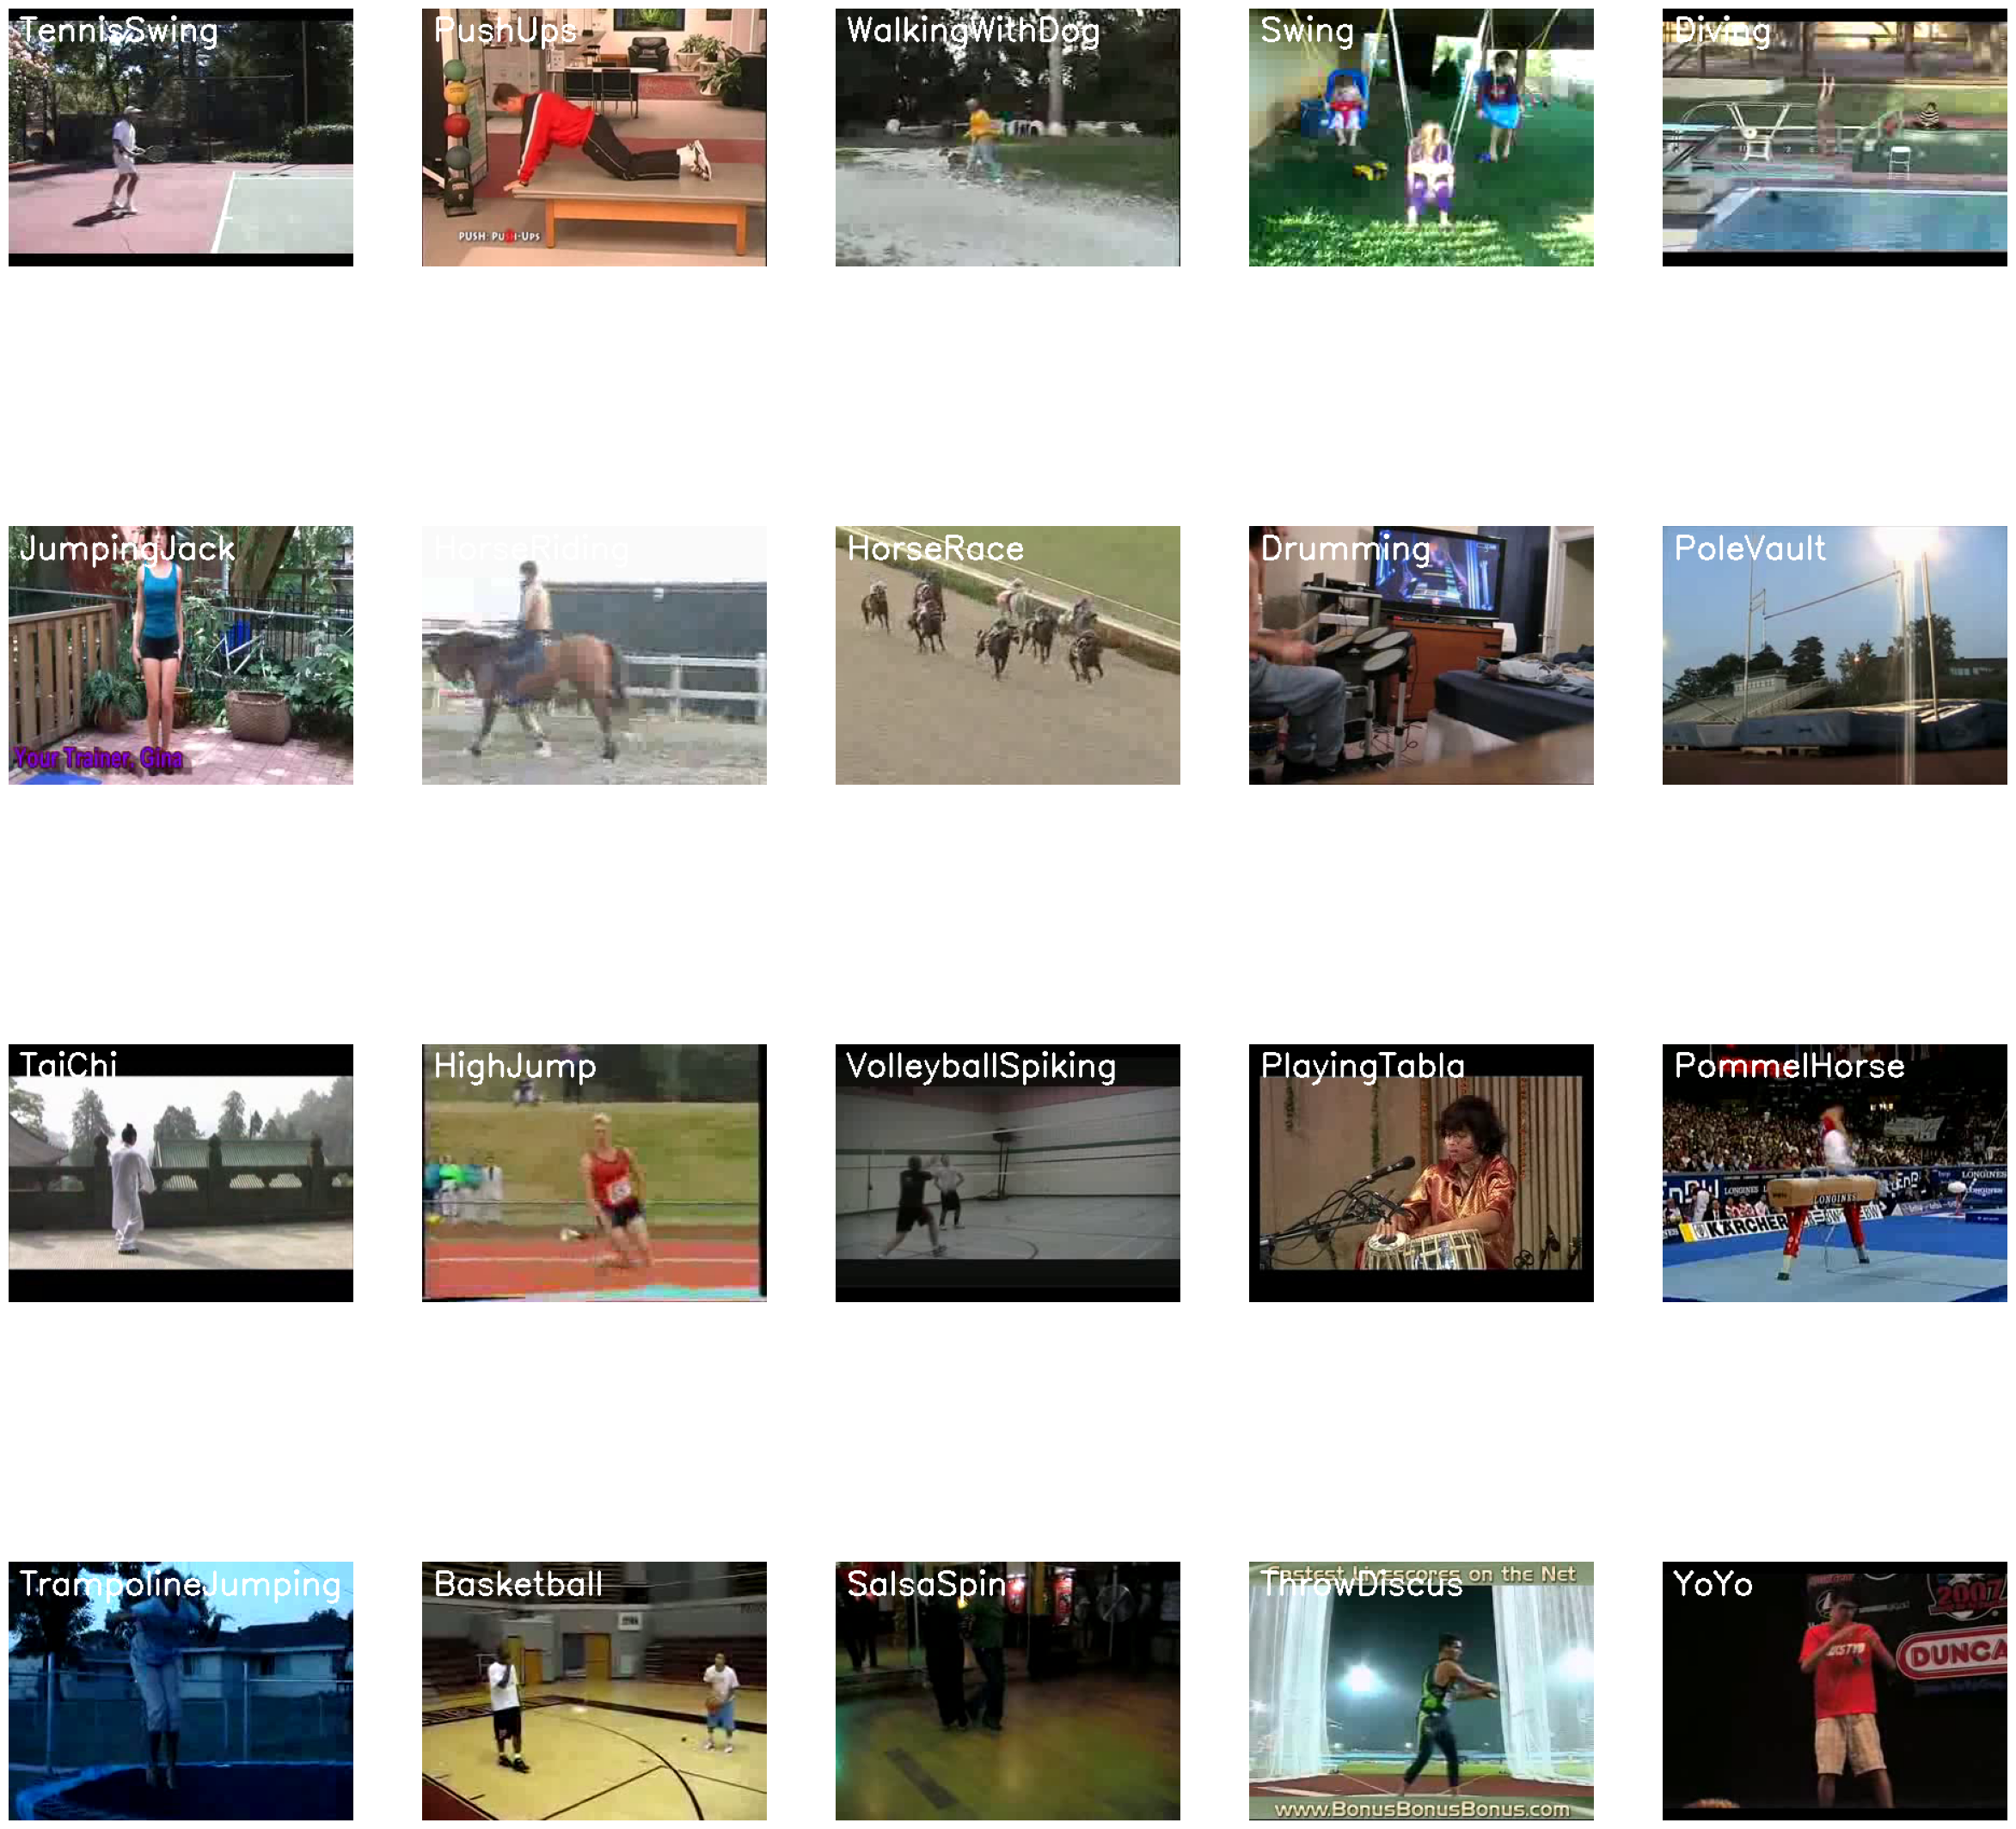

In [5]:
import random

plt.figure(figsize=(30, 30))
all_classes_names = os.listdir('UCF20')

for counter, selected_class_Name in enumerate(all_classes_names, 1): #enumerate اعضای کلاس را با یک اندیس بررمی گرداند
    video_files_names_list = os.listdir(f'UCF20/{selected_class_Name}')

    # Check if there are video files in the folder
    if video_files_names_list:
        selected_video_file_name = random.choice(video_files_names_list)
        video_reader = cv2.VideoCapture(f'UCF20/{selected_class_Name}/{selected_video_file_name}')
        _, bgr_frame = video_reader.read()
        video_reader.release()
        rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
        cv2.putText(rgb_frame, selected_class_Name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        plt.subplot(4,5 , counter)  # Adjust the number of rows and columns as needed
        plt.imshow(rgb_frame)
        plt.axis('off')
    else:
        print(f"No video files found in folder {selected_class_Name}")

plt.show()

IMAGE_HEIGHT,IMAGE_WIDTH = 64,64
SEQUENCE_LENGTH = 20
DATASET_DIR="UCF20"
CLASSES_LIST = ["PlayingTabla", "PommelHorse", "JumpingJack", "PushUps", "PoleVault",
                "HorseRace", "HighJump", "Drumming", "HorseRiding", "Diving",
                "Basketball", "TrampolineJumping", "YoYo", "SalsaSpin", "WalkingWithDog",
                "VolleyballSpiking", "ThrowDiscus", "TennisSwing", "TaiChi", "Swing"]

In [6]:
def frames_extraction(video_path):
  frames_list=[]
  video_reader = cv2.VideoCapture(video_path)
  video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
  skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH),1)
  for frame_counter in range(SEQUENCE_LENGTH):
    video_reader.set(cv2.CAP_PROP_POS_FRAMES,frame_counter*skip_frames_window)
    success,frame = video_reader.read()
    if not success:
      break

    resized_frame = cv2.resize(frame,(IMAGE_HEIGHT,IMAGE_WIDTH))
    normalized_frame = resized_frame / 255
    frames_list.append(normalized_frame)
  video_reader.release()

  return frames_list

def create_dataset():
  features = []
  labels = []
  video_files_paths = []
  for class_index,class_name in enumerate(CLASSES_LIST[:20]):
    print(f'Extracting Data of CLass: {class_name}')

    files_list = os.listdir(os.path.join(DATASET_DIR,class_name))
    for file_name in files_list:
      video_file_path = os.path.join(DATASET_DIR,class_name,file_name)

      frames = frames_extraction(video_file_path)
      if len(frames) == SEQUENCE_LENGTH:
        features.append(frames)
        labels.append(class_index)
        video_files_paths.append(video_file_path)
  features = np.asarray(features)
  labels = np.array(labels)

  return features,labels,video_files_paths
features,labels,video_files_paths = create_dataset()
one_hot_encoded_labels = to_categorical(labels)

Extracting Data of CLass: PlayingTabla
Extracting Data of CLass: PommelHorse
Extracting Data of CLass: JumpingJack
Extracting Data of CLass: PushUps
Extracting Data of CLass: PoleVault
Extracting Data of CLass: HorseRace
Extracting Data of CLass: HighJump
Extracting Data of CLass: Drumming
Extracting Data of CLass: HorseRiding
Extracting Data of CLass: Diving
Extracting Data of CLass: Basketball
Extracting Data of CLass: TrampolineJumping
Extracting Data of CLass: YoYo
Extracting Data of CLass: SalsaSpin
Extracting Data of CLass: WalkingWithDog
Extracting Data of CLass: VolleyballSpiking
Extracting Data of CLass: ThrowDiscus
Extracting Data of CLass: TennisSwing
Extracting Data of CLass: TaiChi
Extracting Data of CLass: Swing


In [7]:
seed_constant = 7
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

features_train,features_test,labels_train,lables_test = train_test_split(features,one_hot_encoded_labels,test_size = 0.25,shuffle = True,random_state = seed_constant)


In [8]:
def create_LRCN_model():


    model = Sequential()

    #Model Architecture.
    #---------------------------------------------------------------------------------------------------------------------------------------------------#

    model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same',activation = 'relu'),
                              input_shape = (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    #model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Flatten()))

    #K-LAYERED LSTM K=1
    model.add(LSTM(32))

    model.add(Dense(len(CLASSES_LIST[:20]), activation = 'softmax'))

    #------------------------------------------------------------------------------------------------------------------------------------------------#

    model.summary()


    return model
LRCN_model = create_LRCN_model()

print("Model Created Successfully!")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDist  (None, 20, 64, 64, 16)    448       
 ributed)                                                        
                                                                 
 time_distributed_1 (TimeDi  (None, 20, 16, 16, 16)    0         
 stributed)                                                      
                                                                 
 time_distributed_2 (TimeDi  (None, 20, 16, 16, 16)    0         
 stributed)                                                      
                                                                 
 time_distributed_3 (TimeDi  (None, 20, 16, 16, 32)    4640      
 stributed)                                                      
                                                                 
 time_distributed_4 (TimeDi  (None, 20, 4, 4, 32)      0

In [9]:
def plot_metric(model_training_history,metric_name1,metric_name2,plot_name):
  metric_value1 = model_training_history.history[metric_name1]
  metric_value2 = model_training_history.history[metric_name2]

  epochs = range(len(metric_value1))

  plt.plot(epochs,metric_value1,'blue',label=metric_name1)
  plt.plot(epochs,metric_value2,'red',label=metric_name2)
  plt.title(str(plot_name))

  plt.legend()

In [13]:
import time
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# قبل از شروع آموزش
start_time = time.time()

# تنظیم EarlyStopping
early_stopping_callback = EarlyStopping(monitor='accuracy', patience=10, mode='max', restore_best_weights=True)

# تنظیم ModelCheckpoint
model_checkpoint_callback = ModelCheckpoint(
    filepath="weights_epoch_{epoch:02d}_val_acc_{val_accuracy:.2f}.h5",  # نام فایل وزن‌ها
    monitor='val_accuracy',  # معیار مورد نظر برای ذخیره (اینجا اعتبارسنجی دقت)
    save_best_only=False,    # ذخیره وزن‌ها در همه epochها
    save_weights_only=True,  # فقط وزن‌ها ذخیره شوند
    verbose=1                # نمایش پیام هنگام ذخیره وزن‌ها
)

# کامپایل کردن مدل
LRCN_model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=["accuracy"])

# شروع آموزش
LRCN_model_training_history = LRCN_model.fit(
    x=features_train,
    y=labels_train,
    epochs=100,
    batch_size=4,
    verbose=2,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback, model_checkpoint_callback]  # اضافه کردن ModelCheckpoint
)

# پایان زمان پس از آموزش
end_time = time.time()

# محاسبه کل زمان آموزش
total_training_time = end_time - start_time
print(f"Total training time: {total_training_time:.2f} seconds")

# ارزیابی مدل
model_evaluation_history = LRCN_model.evaluate(features_test, labeles_test)


Epoch 1/100

Epoch 1: saving model to weights_epoch_01_val_acc_0.65.h5
392/392 - 56s - loss: 0.6986 - accuracy: 0.7923 - val_loss: 1.1967 - val_accuracy: 0.6531 - 56s/epoch - 142ms/step
Epoch 2/100

Epoch 2: saving model to weights_epoch_02_val_acc_0.66.h5
392/392 - 49s - loss: 0.6557 - accuracy: 0.8032 - val_loss: 1.1657 - val_accuracy: 0.6633 - 49s/epoch - 125ms/step
Epoch 3/100

Epoch 3: saving model to weights_epoch_03_val_acc_0.68.h5
392/392 - 49s - loss: 0.6316 - accuracy: 0.8096 - val_loss: 1.0506 - val_accuracy: 0.6760 - 49s/epoch - 125ms/step
Epoch 4/100

Epoch 4: saving model to weights_epoch_04_val_acc_0.62.h5
392/392 - 50s - loss: 0.6125 - accuracy: 0.8121 - val_loss: 1.2149 - val_accuracy: 0.6250 - 50s/epoch - 127ms/step
Epoch 5/100

Epoch 5: saving model to weights_epoch_05_val_acc_0.66.h5
392/392 - 50s - loss: 0.5970 - accuracy: 0.8198 - val_loss: 1.1577 - val_accuracy: 0.6607 - 50s/epoch - 127ms/step
Epoch 6/100

Epoch 6: saving model to weights_epoch_06_val_acc_0.66.h5

NameError: name 'labels_test' is not defined

In [16]:
# total training time
total_training_time = end_time - start_time
print(f"Total training time: {total_training_time:.2f} seconds")
model_evaluation_history = LRCN_model.evaluate(features_test,lables_test)

Total training time: 2453.18 seconds
21/21 [==============================] - 8s 324ms/step - loss: 0.8000 - accuracy: 0.8469


In [20]:
import os
from moviepy.editor import VideoFileClip
test_videos_directory='test_videos'
os.makedirs(test_videos_directory,exist_ok=True)


input_video_file_path = '/content/UCF20/Basketball/v_Basketball_g01_c01.avi'

video_title = os.path.splitext(os.path.basename(input_video_file_path))[0]

print(f"Video Name: {video_title}")

KeyboardInterrupt: 

In [21]:
import os
import cv2

# مسیر ذخیره‌سازی ویدئوهای تست
test_videos_directory = 'test_videos'
os.makedirs(test_videos_directory, exist_ok=True)

# مسیر فایل ورودی ویدئو
input_video_file_path = '/content/UCF20/Basketball/v_Basketball_g01_c01.avi'

# استخراج نام ویدئو از مسیر
video_title = os.path.splitext(os.path.basename(input_video_file_path))[0]

# خواندن اطلاعات ویدئو با OpenCV
video_capture = cv2.VideoCapture(input_video_file_path)

# بررسی اگر ویدئو باز شود
if not video_capture.isOpened():
    print(f"Error: Unable to open video file {input_video_file_path}")
else:
    print(f"Video Name: {video_title}")
    print(f"Video Frame Width: {int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))}")
    print(f"Video Frame Height: {int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))}")
    print(f"Video Frame Count: {int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))}")
    print(f"Video FPS: {int(video_capture.get(cv2.CAP_PROP_FPS))}")

# بستن ویدئو پس از خواندن اطلاعات
video_capture.release()


Video Name: v_Basketball_g01_c01
Video Frame Width: 320
Video Frame Height: 240
Video Frame Count: 141
Video FPS: 29


In [22]:
def predict_on_video(video_file_path, output_file_path, SEQUENCE_LENGTH):
    video_reader = cv2.VideoCapture(video_file_path)

    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc('M', 'P', '4', 'V'),
                                  video_reader.get(cv2.CAP_PROP_FPS), (original_video_width, original_video_height))

    frames_queue = deque(maxlen=SEQUENCE_LENGTH)

    predicted_class_name = ''

    while video_reader.isOpened():
        ok, frame = video_reader.read()
        if not ok:
            break  # Exit the loop when there are no more frames

        # Check if the frame is empty before resizing
        if not frame.size:
            continue

        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255
        frames_queue.append(normalized_frame)

        if len(frames_queue) == SEQUENCE_LENGTH:
            predicted_labels_probabilities = LRCN_model.predict(np.expand_dims(frames_queue, axis=0))[0]
            predicted_label = np.argmax(predicted_labels_probabilities)

            predicted_class_name = CLASSES_LIST[predicted_label]

            cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            video_writer.write(frame)

    video_reader.release()
    video_writer.release()

In [56]:
true_labels = []  # true labels for each frame
predicted_labels = []  # predicted labels for each frame
#predict labels for a video
def predict_on_video(video_file_path, true_label):
    video_reader = cv2.VideoCapture(video_file_path)
    frames_queue = deque(maxlen=SEQUENCE_LENGTH)

    while video_reader.isOpened():
        ok, frame = video_reader.read()
        if not ok:
            break


        if not frame.size:
            continue

        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255
        frames_queue.append(normalized_frame)

        if len(frames_queue) == SEQUENCE_LENGTH:

            predicted_labels_probabilities = LRCN_model.predict(np.expand_dims(frames_queue, axis=0))[0]
            predicted_label = np.argmax(predicted_labels_probabilities)

            predicted_class_name = CLASSES_LIST[predicted_label]


            true_labels.append(true_label)
            predicted_labels.append(predicted_class_name)

    video_reader.release()

    return true_labels, predicted_labels

#test vids
class_name_mapping = {
    'v_Diving_g01_c02': 'Diving',
    'v_Drumming_g04_c01': 'Drumming',
    'v_HighJump_g01_c04': 'HighJump',
    'v_HorseRace_g02_c03': 'HorseRace',
    'v_HorseRiding_g01_c03': 'HorseRiding',
    'v_JumpingJack_g01_c03': 'JumpingJack',
    'v_PlayingTabla_g05_c03': 'PlayingTabla',
    'v_PoleVault_g03_c03': 'PoleVault',
    'v_TaiChi_g02_c04': 'TaiChi',
    'v_VolleyballSpiking_g02_c04': 'VolleyballSpiking',
}

all_true_labels = []
all_predicted_labels = []


test_videos_directory = '/content/Test_dir'

for video_file in os.listdir(test_videos_directory):
    if video_file.endswith(".avi"):
        video_file_path = os.path.join(test_videos_directory, video_file)
        video_title = os.path.splitext(os.path.basename(video_file_path))[0]
        print(video_file_path)
        # Map video_title
        class_name = class_name_mapping.get(video_title, 'Unknown')


        true_labels_video, predicted_labels_video = predict_on_video(video_file_path, true_label=class_name)

        all_true_labels.extend(true_labels_video)
        all_predicted_labels.extend(predicted_labels_video)
print(all_true_labels)
print(all_predicted_labels)

/content/Test_dir/v_VolleyballSpiking_g02_c04.avi
1/1 [==============================] - 0s 28ms/step
/content/Test_dir/v_Drumming_g04_c01.avi
1/1 [==============================] - 0s 27ms/step
/content/Test_dir/v_JumpingJack_g01_c03.avi
1/1 [==============================] - 0s 27ms/step
/content/Test_dir/v_HighJump_g01_c04.avi
1/1 [==============================] - 0s 33ms/step
/content/Test_dir/v_HorseRace_g02_c03.avi
1/1 [==============================] - 0s 31ms/step
/content/Test_dir/v_TaiChi_g02_c04.avi
1/1 [==============================] - 0s 28ms/step
/content/Test_dir/v_PoleVault_g03_c03.avi
1/1 [==============================] - 0s 28ms/step
/content/Test_dir/v_PlayingTabla_g05_c03.avi
1/1 [==============================] - 0s 27ms/step
/content/Test_dir/v_Diving_g01_c02.avi
1/1 [==============================] - 0s 26ms/step
/content/Test_dir/v_HorseRiding_g01_c03.avi
1/1 [==============================] - 0s 28ms/step
['VolleyballSpiking', 'VolleyballSpiking', 'Volleybal

In [57]:
from sklearn.metrics import classification_report

# ایجاد لیست از کلاس‌های موجود در داده‌های تست
unique_classes_in_test = list(set(all_true_labels))  # مجموعه برچسب‌های واقعی در داده‌های تست

# چاپ گزارش فقط برای کلاس‌هایی که در داده‌های تست وجود دارند
report = classification_report(all_true_labels, all_predicted_labels, labels=unique_classes_in_test)
print(report)


                   precision    recall  f1-score   support

         HighJump       1.00      0.02      0.04      1120
      JumpingJack       0.71      1.00      0.83       584
        HorseRace       0.72      0.34      0.47      1764
           TaiChi       1.00      1.00      1.00       760
           Diving       1.00      0.94      0.97       526
        PoleVault       0.98      0.72      0.83       812
      HorseRiding       0.92      1.00      0.96        79
     PlayingTabla       1.00      1.00      1.00       723
VolleyballSpiking       0.44      1.00      0.61       720
         Drumming       0.91      1.00      0.95      2529

        micro avg       0.81      0.74      0.77      9617
        macro avg       0.87      0.80      0.77      9617
     weighted avg       0.86      0.74      0.72      9617



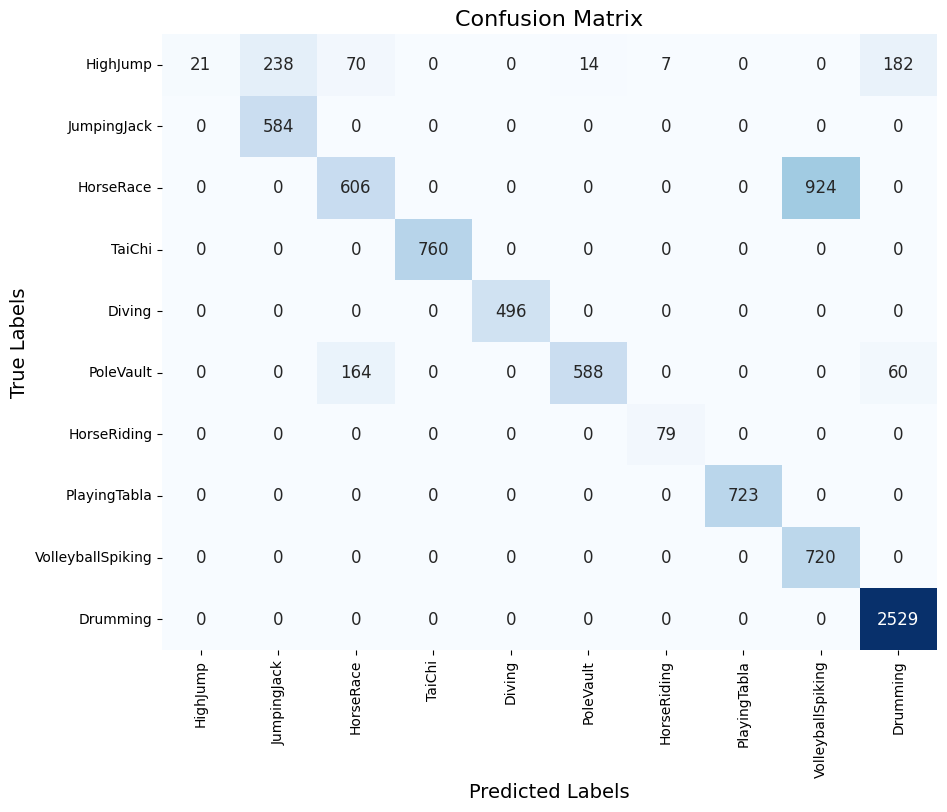

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ایجاد لیست از کلاس‌های موجود در داده‌های تست
unique_classes_in_test = list(set(all_true_labels))  # مجموعه برچسب‌های واقعی در داده‌های تست

# محاسبه ماتریس سردرگمی فقط برای کلاس‌هایی که در داده‌های تست وجود دارند
confusion = confusion_matrix(all_true_labels, all_predicted_labels, labels=unique_classes_in_test)

# ساخت یک DataFrame برای نمایش ماتریس با نام کلاس‌ها
confusion_df = pd.DataFrame(confusion, index=unique_classes_in_test, columns=unique_classes_in_test)

# برای ترسیم ماتریس سردرگمی به صورت گرافیکی
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_df, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 12})
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.show()
